<a href="https://colab.research.google.com/github/nouha-rgb/Barcode-QR-detection/blob/main/Projet_CV_QRCODE_BARCODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

In [2]:
!apt-get -qq install -y libzbar0
!pip -q install pyzbar opencv-python

Selecting previously unselected package fonts-droid-fallback.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../00-fonts-droid-fallback_1%3a6.0.1r16-1.1build1_all.deb ...
Unpacking fonts-droid-fallback (1:6.0.1r16-1.1build1) ...
Selecting previously unselected package libfftw3-double3:amd64.
Preparing to unpack .../01-libfftw3-double3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously unselected package liblqr-1-0:amd64.
Preparing to unpack .../02-liblqr-1-0_0.4.2-2.1_amd64.deb ...
Unpacking liblqr-1-0:amd64 (0.4.2-2.1) ...
Selecting previously unselected package imagemagick-6-common.
Preparing to unpack .../03-imagemagick-6-common_8%3a6.9.11.60+dfsg-1.3ubuntu0.22.04.5_all.deb ...
Unpacking imagemagick-6-common (8:6.9.11.60+dfsg-1.3ubuntu0.22.04.5) ...
Selecting previously unselected package libmagickcore-6.q16-6:amd64.
Preparing to unpack .../04-libmagickcore-6.q16-6_8%3a6.9.11.60+dfsg-

# Helper functions to display images

In [3]:
def show_image(img, title="", cmap=None, figsize=(6,6)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


def normalize_to_uint8(arr):
    arr = arr.astype(np.float32)
    arr = arr - arr.min()
    if arr.max() > 0:
        arr = arr / arr.max()
    arr = (arr * 255).clip(0, 255).astype(np.uint8)
    return arr

# Load image

In [4]:
import requests
from io import BytesIO

def load_image_from_url(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    return np.array(img)

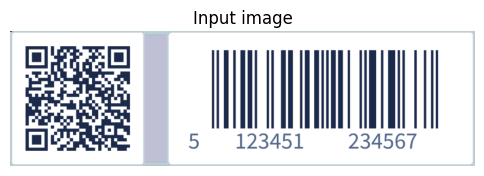

In [5]:
img = load_image_from_url(
    "https://fr.qr-code-generator.com/wp-content/themes/qr/new_structure/assets/media/images/solutions/overview/QRCodeBarcode.png"
)

show_image(img, "Input image")

# Convert RGB to grayscale

In [6]:
def rgb_to_grayscale(img):
    # img shape: (H, W, 3)
    gray = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]
    return gray.astype(np.float32)

# Padding function

In [7]:
#We need this for convolution
def pad_image(img, pad_h, pad_w, mode='edge'):
    return np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode=mode)

# Generic 2D convolution

In [8]:
def convolve2d(image, kernel):
    image = image.astype(np.float32)
    kernel = np.array(kernel, dtype=np.float32)

    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2

    padded = pad_image(image, pad_h, pad_w, mode='edge')
    output = np.zeros_like(image, dtype=np.float32)

    # flip kernel for true convolution
    kernel = np.flipud(np.fliplr(kernel))

    H, W = image.shape
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return output

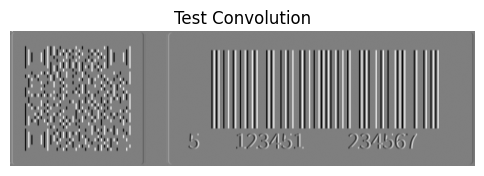

In [9]:
# test de convolution
test_kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
], dtype=np.float32)

gray = rgb_to_grayscale(img)
edge_test = convolve2d(gray, test_kernel)
show_image(normalize_to_uint8(edge_test), "Test Convolution", cmap="gray")

# Gaussian blur from scratch

In [10]:
#First create the Gaussian kernel.
def gaussian_kernel(size=5, sigma=1.0):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= np.sum(kernel)
    return kernel.astype(np.float32)

In [11]:
#Apply blur
def gaussian_blur(image, size=5, sigma=1.0):
  image = image.astype(np.float32)
  kernel = gaussian_kernel(size=size, sigma=sigma)
  return convolve2d(image, kernel)

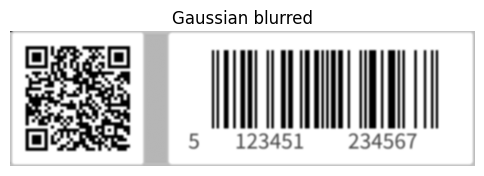

In [12]:
#Test
blurred = gaussian_blur(gray, size=5, sigma=2)
show_image(blurred, "Gaussian blurred", cmap="gray")

# Sobel gradients

For barcodes, the important thing is the x-gradient, because barcode bars are vertical, so intensity changes horizontally.

In [13]:
def sobel_gradients(image):
    Kx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float32)

    Ky = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]], dtype=np.float32)

    gx = convolve2d(image, Kx)
    gy = convolve2d(image, Ky)

    magnitude = np.sqrt(gx**2 + gy**2)
    return gx, gy, magnitude

# Barcode emphasis

A barcode should have much stronger structure in one direction.

A simple idea is to emphasize horizontal intensity variation:

In [14]:
def barcode_response(gx, gy):
    response = np.abs(gx) - np.abs(gy)
    response = np.maximum(response, 0)
    return response


def threshold_image(image, thresh):
    return (image >= thresh).astype(np.uint8)

# Thresholding

Since response values vary by image, we use a relative threshold:

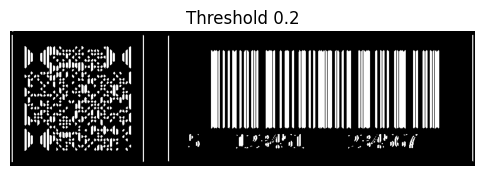

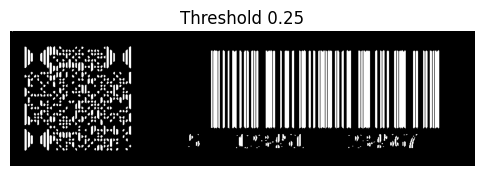

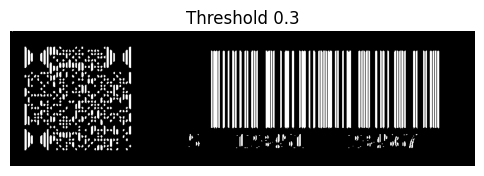

In [15]:
gray = rgb_to_grayscale(img)
blurred = gaussian_blur(gray, size=3, sigma=1.2)
gx, gy, _ = sobel_gradients(blurred)

resp = barcode_response(gx, gy)
resp_norm = resp / (resp.max() + 1e-8)

for t in [0.2, 0.25, 0.3]:
    binary = threshold_image(resp_norm, t)
    show_image(binary * 255, f"Threshold {t}", cmap="gray")

# Morphology from scratch

We now need to merge many thin stripe fragments into one region.

**Dilation**

In [16]:
def dilate(binary, kernel_shape=(3, 3), iterations=1):
    out = binary.copy()
    kh, kw = kernel_shape
    pad_h = kh // 2
    pad_w = kw // 2

    for _ in range(iterations):
        padded = np.pad(out, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
        new_out = np.zeros_like(out)

        H, W = out.shape
        for i in range(H):
            for j in range(W):
                region = padded[i:i+kh, j:j+kw]
                new_out[i, j] = 1 if np.any(region == 1) else 0

        out = new_out

    return out

#If barcode exists nearby, assume this pixel is also part of it
#This means:

check 3x3 neighborhood

Small kernel:subtle expansion  preserves

shapeLarge kernel:aggressive mergingmay merge wrong region

**Erosion**

In [17]:
def erode(binary, kernel_size=3, iterations=1):
    out = binary.copy()
    pad = kernel_size // 2

    for _ in range(iterations):
        padded = np.pad(out, ((pad, pad), (pad, pad)), mode='constant')
        new_out = np.zeros_like(out)

        H, W = out.shape
        for i in range(H):
            for j in range(W):
                region = padded[i:i+kernel_size, j:j+kernel_size]
                new_out[i, j] = 1 if np.all(region == 1) else 0

        out = new_out

    return out

**Closing = dilation then erosion**

In [18]:
def closing(binary, kernel_size=5, iterations=1):
    return erode(dilate(binary, kernel_size, iterations), kernel_size, iterations)

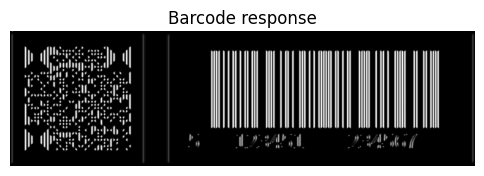

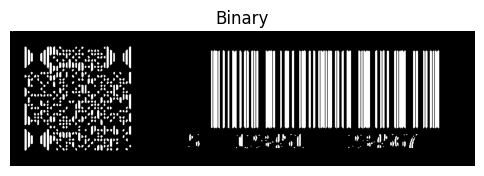

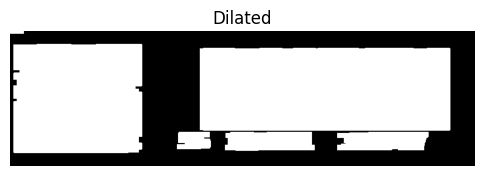

In [19]:
gx, gy, _ = sobel_gradients(blurred)

resp = barcode_response(gx, gy)
resp_norm = resp / (resp.max() + 1e-8)

binary = threshold_image(resp_norm, 0.25)

# dilation rectangulaire : fusion horizontale plus forte
dilated = dilate(binary, kernel_shape=(5, 21), iterations=2)

show_image(normalize_to_uint8(resp), "Barcode response", cmap="gray")
show_image(binary * 255, "Binary", cmap="gray")
show_image(dilated * 255, "Dilated", cmap="gray")

# Connected components from scratch

Now we want to find separate blobs.

In [20]:
def connected_components(binary):
    H, W = binary.shape
    visited = np.zeros((H, W), dtype=bool)
    components = []

    for i in range(H):
        for j in range(W):
            if binary[i, j] == 1 and not visited[i, j]:
                stack = [(i, j)]
                visited[i, j] = True
                pixels = []

                while stack:
                    x, y = stack.pop()
                    pixels.append((x, y))

                    for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1),
                                   (-1, -1), (-1, 1), (1, -1), (1, 1)]:
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < H and 0 <= ny < W:
                            if binary[nx, ny] == 1 and not visited[nx, ny]:
                                visited[nx, ny] = True
                                stack.append((nx, ny))

                components.append(pixels)

    return components


def component_bounding_box(component):
    rows = [p[0] for p in component]
    cols = [p[1] for p in component]
    return min(rows), min(cols), max(rows), max(cols)

In [21]:
def draw_component_boxes(image, components, min_size=50):
    out = Image.fromarray(image.astype(np.uint8))
    draw = ImageDraw.Draw(out)

    for comp in components:
        if len(comp) < min_size:
            continue

        r_min, c_min, r_max, c_max = component_bounding_box(comp)
        draw.rectangle([c_min, r_min, c_max, r_max], outline=(255, 0, 0), width=2)

    return np.array(out)

Number of components: 6
Sizes of first components: [125, 44630, 66337, 1750, 5128, 5030]


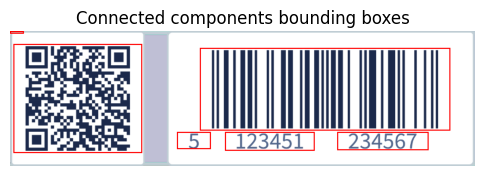

In [22]:
components = connected_components(dilated)

print("Number of components:", len(components))
print("Sizes of first components:", [len(c) for c in components[:10]])

boxed = draw_component_boxes(img, components, min_size=100)
show_image(boxed, "Connected components bounding boxes")

# Filter barcode candidates

A barcode candidate is usually:
- not too small
- rectangular
- often wider than tall
- contains enough pixels

Barcode = MANY vertical stripes

 Key idea:

Barcode has high variation in X direction
Text does NOT have regular repetition

In [23]:
def count_transitions(region):
    if region.shape[0] == 0 or region.shape[1] == 0:
        return 0

    transitions = 0
    threshold = np.mean(region)

    for row in region:
        binary_row = row > threshold
        transitions += np.sum(binary_row[:-1] != binary_row[1:])

    return transitions / region.shape[0]

In [24]:
def filter_barcode_candidates_final(components, gray, gx, gy):
    candidates = []

    for idx, comp in enumerate(components):
        r_min, c_min, r_max, c_max = component_bounding_box(comp)

        h = r_max - r_min + 1
        w = c_max - c_min + 1

        if h <= 0 or w <= 0:
            continue

        area_pixels = len(comp)
        aspect_ratio = w / h

        region = gray[r_min:r_max+1, c_min:c_max+1]
        transitions = count_transitions(region)

        gx_region = gx[r_min:r_max+1, c_min:c_max+1]
        gy_region = gy[r_min:r_max+1, c_min:c_max+1]
        edge_ratio = np.mean(np.abs(gx_region)) / (np.mean(np.abs(gy_region)) + 1e-8)

        fill_ratio = area_pixels / (h * w)

        print(f"\nComponent {idx+1}")
        print("Box         :", (r_min, c_min, r_max, c_max))
        print("Aspect ratio:", aspect_ratio)
        print("Pixel area  :", area_pixels)
        print("Transitions :", transitions)
        print("Edge ratio  :", edge_ratio)
        print("Fill ratio  :", fill_ratio)

        if aspect_ratio < 1.2:
            continue
        if area_pixels < 300:
            continue
        if transitions < 2:
            continue
        if edge_ratio < 1.2:
            continue
        if fill_ratio < 0.05:
            continue

        candidates.append({
            "box": (r_min, c_min, r_max, c_max),
            "aspect_ratio": aspect_ratio,
            "area_pixels": area_pixels,
            "transitions": transitions,
            "edge_ratio": edge_ratio,
            "fill_ratio": fill_ratio
        })

    return candidates

In [25]:
def select_best_candidate(candidates):
    if len(candidates) == 0:
        return None

    # score simple basé sur transitions + edge dominance
    best = max(
        candidates,
        key=lambda c: c["transitions"] * c["edge_ratio"]
    )

    return best

In [26]:
candidates = filter_barcode_candidates_final(
    components,
    gray,
    gx,
    gy
)

print("Number of advanced candidates:", len(candidates))

for i, cand in enumerate(candidates, 1):
    print(f"\nCandidate {i}")
    print("Box         :", cand["box"])
    print("Aspect ratio:", cand["aspect_ratio"])
    print("Pixel area  :", cand["area_pixels"])
    print("Transitions :", cand["transitions"])
    print("Edge ratio  :", cand["edge_ratio"])
    print("Fill ratio  :", cand["fill_ratio"])


Component 1
Box         : (0, 0, 4, 24)
Aspect ratio: 5.0
Pixel area  : 125
Transitions : 0.4
Edge ratio  : 0.1941286
Fill ratio  : 1.0

Component 2
Box         : (23, 6, 217, 236)
Aspect ratio: 1.1846153846153846
Pixel area  : 44630
Transitions : 16.6974358974359
Edge ratio  : 0.98474455
Fill ratio  : 0.9907869907869908

Component 3
Box         : (30, 340, 177, 788)
Aspect ratio: 3.0337837837837838
Pixel area  : 66337
Transitions : 56.75675675675676
Edge ratio  : 22.124718
Fill ratio  : 0.9982694275567326

Component 4
Box         : (180, 299, 210, 359)
Aspect ratio: 1.967741935483871
Pixel area  : 1750
Transitions : 2.129032258064516
Edge ratio  : 0.825668
Fill ratio  : 0.9254362771020624

Component 5
Box         : (180, 385, 213, 545)
Aspect ratio: 4.735294117647059
Pixel area  : 5128
Transitions : 11.058823529411764
Edge ratio  : 1.0364028
Fill ratio  : 0.9367921081476068

Component 6
Box         : (180, 586, 212, 749)
Aspect ratio: 4.96969696969697
Pixel area  : 5030
Transitions :

In [27]:
def draw_candidate_boxes(image, candidates):
    out = Image.fromarray(image.astype(np.uint8))
    draw = ImageDraw.Draw(out)

    for cand in candidates:
        r_min, c_min, r_max, c_max = cand["box"]
        draw.rectangle([c_min, r_min, c_max, r_max], outline=(0, 255, 0), width=3)

    return np.array(out)

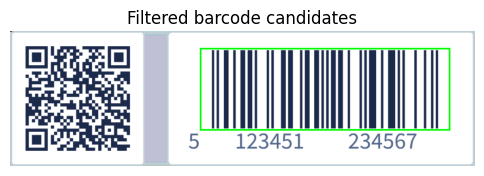

In [28]:
candidate_img = draw_candidate_boxes(img, candidates)
show_image(candidate_img, "Filtered barcode candidates")

# Draw boxes

In [29]:
from PIL import Image, ImageDraw

def draw_boxes(image, candidates, color=(255, 0, 0), width=3):
    pil_img = Image.fromarray(image.astype(np.uint8))
    draw = ImageDraw.Draw(pil_img)

    for cand in candidates:
        r_min, c_min, r_max, c_max = cand["box"]
        draw.rectangle([c_min, r_min, c_max, r_max], outline=color, width=width)

    return np.array(pil_img)

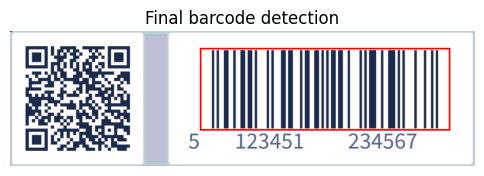

In [30]:
best = select_best_candidate(candidates)

result_img = draw_boxes(img, [best])
show_image(result_img, "Final barcode detection")

# Full barcode localization pipeline

Now combine everything.

In [31]:
def detect_barcodes(image):
    gray = rgb_to_grayscale(image)
    blurred = gaussian_blur(gray, size=3, sigma=1.2)

    gx, gy, _ = sobel_gradients(blurred)

    # barcode response
    resp = barcode_response(gx, gy)
    resp_norm = resp / (resp.max() + 1e-8)

    # threshold + morphology
    binary = threshold_image(resp_norm, 0.25)
    dilated = dilate(binary, kernel_shape=(5, 21), iterations=2)

    # connected components
    components = connected_components(dilated)

    # candidate filtering
    candidates = filter_barcode_candidates_final(
        components,
        gray,
        gx,
        gy
    )

    # keep best only
    best = select_best_candidate(candidates)

    if best is None:
        result = image.copy()
        final_candidates = []
    else:
        result = draw_boxes(image, [best])
        final_candidates = [best]

    debug = {
        "gray": gray,
        "blurred": blurred,
        "resp": resp,
        "binary": binary,
        "dilated": dilated,
        "components": components,
        "all_candidates": candidates,
        "best_candidate": best
    }

    return result, final_candidates, debug


Component 1
Box         : (0, 0, 4, 24)
Aspect ratio: 5.0
Pixel area  : 125
Transitions : 0.4
Edge ratio  : 0.1941286
Fill ratio  : 1.0

Component 2
Box         : (23, 6, 217, 236)
Aspect ratio: 1.1846153846153846
Pixel area  : 44630
Transitions : 16.6974358974359
Edge ratio  : 0.98474455
Fill ratio  : 0.9907869907869908

Component 3
Box         : (30, 340, 177, 788)
Aspect ratio: 3.0337837837837838
Pixel area  : 66337
Transitions : 56.75675675675676
Edge ratio  : 22.124718
Fill ratio  : 0.9982694275567326

Component 4
Box         : (180, 299, 210, 359)
Aspect ratio: 1.967741935483871
Pixel area  : 1750
Transitions : 2.129032258064516
Edge ratio  : 0.825668
Fill ratio  : 0.9254362771020624

Component 5
Box         : (180, 385, 213, 545)
Aspect ratio: 4.735294117647059
Pixel area  : 5128
Transitions : 11.058823529411764
Edge ratio  : 1.0364028
Fill ratio  : 0.9367921081476068

Component 6
Box         : (180, 586, 212, 749)
Aspect ratio: 4.96969696969697
Pixel area  : 5030
Transitions :

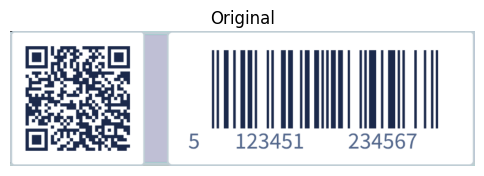

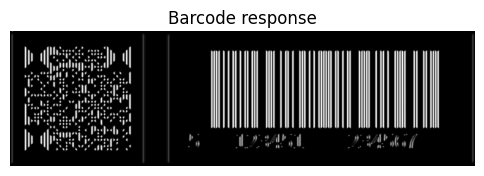

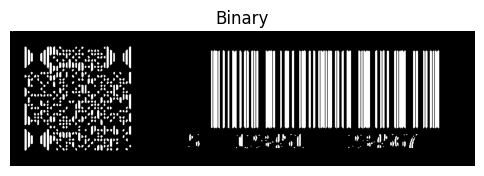

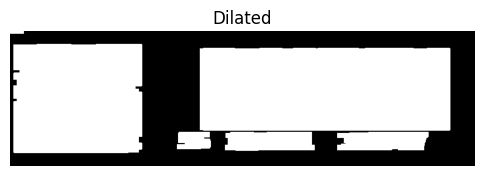

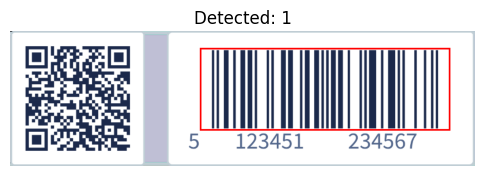

In [32]:
result, candidates, debug = detect_barcodes(img)

show_image(img, "Original")
show_image(normalize_to_uint8(debug["resp"]), "Barcode response", cmap="gray")
show_image(debug["binary"] * 255, "Binary", cmap="gray")
show_image(debug["dilated"] * 255, "Dilated", cmap="gray")
show_image(result, f"Detected: {len(candidates)}")

# 2-Local thresholding

Global threshold can fail if lighting changes.
So let’s implement a simple local mean threshold.

For each pixel:

- compute mean of a window around it
- if pixel is darker than local mean minus a constant, mark it black

Here:

- 1 means black/foreground
- 0 means background

In [33]:
import cv2
from pyzbar.pyzbar import decode

In [34]:
def generate_barcode_versions(roi):
    versions = []

    gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    big = cv2.resize(gray, None, fx=2.5, fy=2.5, interpolation=cv2.INTER_CUBIC)

    versions.append(("original", roi))
    versions.append(("gray_big", big))
    versions.append(("gray", gray))

    eq = cv2.equalizeHist(big)
    versions.append(("equalized", eq))

    blur = cv2.GaussianBlur(eq, (3, 3), 0)
    versions.append(("blur", blur))

    _, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    versions.append(("otsu", otsu))

    _, otsu_inv = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    versions.append(("otsu_inv", otsu_inv))

    adaptive = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31, 8
    )
    versions.append(("adaptive", adaptive))

    kernel_sharp = np.array([[0, -1, 0],
                             [-1, 5, -1],
                             [0, -1, 0]], dtype=np.float32)
    sharp = cv2.filter2D(big, -1, kernel_sharp)
    versions.append(("sharp", sharp))

    return versions

In [35]:
def try_decode_barcode_roi(roi):
    angles = [0, 90, 180, 270]

    for angle in angles:
        rotated = rotate_image_cv(roi, angle)

        for name, version in generate_barcode_versions(rotated):
            decoded = decode(version)

            if decoded:
                d = decoded[0]
                try:
                    text = d.data.decode("utf-8")
                except Exception:
                    text = str(d.data)

                return {
                    "success": True,
                    "text": text,
                    "type": d.type,
                    "angle": angle,
                    "version": name
                }

    return {
        "success": False,
        "text": None,
        "type": None,
        "angle": None,
        "version": None
    }

In [36]:
def decode_detected_barcodes(image, candidates, padding=12):
    H, W = image.shape[:2]
    decoded_results = []

    for cand in candidates:
        r_min, c_min, r_max, c_max = cand["box"]

        r0 = max(0, r_min - padding)
        c0 = max(0, c_min - padding)
        r1 = min(H - 1, r_max + padding)
        c1 = min(W - 1, c_max + padding)

        roi = image[r0:r1+1, c0:c1+1]
        result = try_decode_barcode_roi(roi)

        decoded_results.append({
            "box": (r_min, c_min, r_max, c_max),
            "padded_box": (r0, c0, r1, c1),
            "decoded": result["success"],
            "text": result["text"],
            "type": result["type"],
            "angle": result["angle"],
            "version": result["version"]
        })

    return decoded_results

In [37]:
def draw_decoded_barcodes(image, decoded_results):
    pil_img = Image.fromarray(image.astype(np.uint8))
    draw = ImageDraw.Draw(pil_img)

    for item in decoded_results:
        r_min, c_min, r_max, c_max = item["box"]

        if item["decoded"]:
            color = (0, 255, 0)
            label = f"{item['type']}: {item['text']}"
        else:
            color = (255, 0, 0)
            label = "BARCODE: not decoded"

        draw.rectangle([c_min, r_min, c_max, r_max], outline=color, width=3)

        text_x = c_min
        text_y = max(0, r_min - 18)
        draw.text((text_x, text_y), label, fill=color)

    return np.array(pil_img)

In [38]:
def detect_and_decode_barcodes(image):
    _, candidates, debug = detect_barcodes(image)
    decoded_results = decode_detected_barcodes(image, candidates)
    final_img = draw_decoded_barcodes(image, decoded_results)
    return final_img, decoded_results, debug

In [39]:
def rotate_image_cv(img, angle):
    if angle == 90:
        return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    elif angle == 180:
        return cv2.rotate(img, cv2.ROTATE_180)
    elif angle == 270:
        return cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
    return img


Component 1
Box         : (0, 0, 4, 24)
Aspect ratio: 5.0
Pixel area  : 125
Transitions : 0.4
Edge ratio  : 0.1941286
Fill ratio  : 1.0

Component 2
Box         : (23, 6, 217, 236)
Aspect ratio: 1.1846153846153846
Pixel area  : 44630
Transitions : 16.6974358974359
Edge ratio  : 0.98474455
Fill ratio  : 0.9907869907869908

Component 3
Box         : (30, 340, 177, 788)
Aspect ratio: 3.0337837837837838
Pixel area  : 66337
Transitions : 56.75675675675676
Edge ratio  : 22.124718
Fill ratio  : 0.9982694275567326

Component 4
Box         : (180, 299, 210, 359)
Aspect ratio: 1.967741935483871
Pixel area  : 1750
Transitions : 2.129032258064516
Edge ratio  : 0.825668
Fill ratio  : 0.9254362771020624

Component 5
Box         : (180, 385, 213, 545)
Aspect ratio: 4.735294117647059
Pixel area  : 5128
Transitions : 11.058823529411764
Edge ratio  : 1.0364028
Fill ratio  : 0.9367921081476068

Component 6
Box         : (180, 586, 212, 749)
Aspect ratio: 4.96969696969697
Pixel area  : 5030
Transitions :

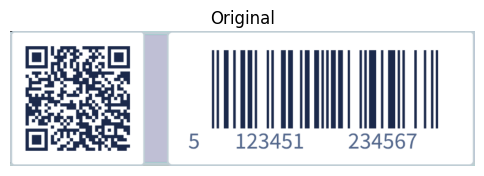

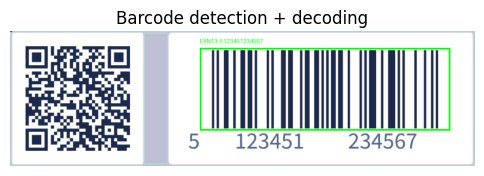

=== Barcode Decoding Results ===

Barcode 1
Box     : (30, 340, 177, 788)
Decoded : True
Text    : 5123451234567
Type    : EAN13
Angle   : 0
Version : original


In [40]:
final_img, decoded_results, debug = detect_and_decode_barcodes(img)

show_image(img, "Original")
show_image(final_img, "Barcode detection + decoding")

print("=== Barcode Decoding Results ===")
for i, item in enumerate(decoded_results, 1):
    print(f"\nBarcode {i}")
    print("Box     :", item["box"])
    print("Decoded :", item["decoded"])
    print("Text    :", item["text"])
    print("Type    :", item["type"])
    print("Angle   :", item["angle"])
    print("Version :", item["version"])

# QR CODE

# Connected components for black regions

We already wrote connected components, and it works directly on binary images.

We can reuse this exact function:

In [41]:
img = load_image_from_url(
    "https://fr.qr-code-generator.com/wp-content/themes/qr/new_structure/assets/media/images/solutions/overview/QRCodeBarcode.png"
)

gray = rgb_to_grayscale(img)
blurred = gaussian_blur(gray, size=5, sigma=1.0)

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import cv2

# Important :

for QR codes, sometimes 8-connectivity works better than 4-connectivity because black regions can touch diagonally. If later your detector misses some regions, we may change this part to 8-neighbors.

In [43]:
def local_mean_threshold(image, window_size=15, C=10):
    """
    Apply local mean thresholding.

    Returns:
        binary image (1 = black, 0 = background)
    """
    image = image.astype(np.float32)

    pad = window_size // 2
    padded = np.pad(image, pad_width=pad, mode='reflect')

    H, W = image.shape
    binary = np.zeros((H, W), dtype=np.uint8)

    for row in range(H):
        for col in range(W):
            window = padded[row:row + window_size, col:col + window_size]
            threshold = np.mean(window) - C
            binary[row, col] = 1 if image[row, col] < threshold else 0

    return binary

In [44]:
def connected_components(binary):
    """
    Find all 8-connected components of foreground pixels (value = 1)
    in a binary image.
    """
    H, W = binary.shape
    visited = np.zeros((H, W), dtype=bool)
    components = []

    neighbors = [
        (-1, 0), (1, 0), (0, -1), (0, 1),
        (-1, -1), (-1, 1), (1, -1), (1, 1)
    ]

    for row in range(H):
        for col in range(W):
            if binary[row, col] != 1 or visited[row, col]:
                continue

            stack = [(row, col)]
            visited[row, col] = True
            component = []

            while stack:
                x, y = stack.pop()
                component.append((x, y))

                for dx, dy in neighbors:
                    nx, ny = x + dx, y + dy

                    if 0 <= nx < H and 0 <= ny < W:
                        if binary[nx, ny] == 1 and not visited[nx, ny]:
                            visited[nx, ny] = True
                            stack.append((nx, ny))

            components.append(component)

    return components

In [45]:
binary = local_mean_threshold(blurred, window_size=15, C=10)
components = connected_components(binary)

Number of components: 65


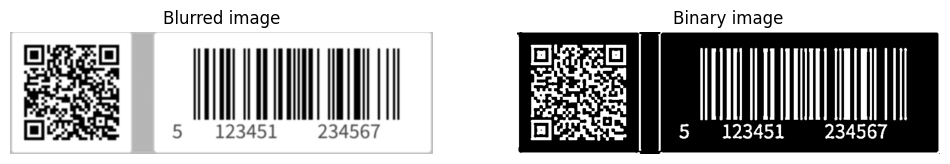

In [46]:
print("Number of components:", len(components))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(blurred, cmap="gray")
plt.title("Blurred image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary image")
plt.axis("off")

plt.show()

# Bounding box helper

In [47]:
def component_bounding_box(component):
    """
    Compute bounding box of a connected component.

    Args:
        component (list): list of (row, col) pixels

    Returns:
        (r_min, c_min, r_max, c_max)
    """
    rows = [p[0] for p in component]
    cols = [p[1] for p in component]

    return min(rows), min(cols), max(rows), max(cols)

# Filter square-like candidates

A QR finder pattern is roughly square.

So let’s keep connected components that:

- are not too small
- have width ≈ height
- have decent fill ratio

components → only square-like → possible QR corners

In [48]:
def filter_square_candidates(components, min_area=80, aspect_tol=0.35, min_fill=0.4):
    """
    Filter connected components that look like squares (QR finder candidates).
    """
    candidates = []

    for comp in components:
        r_min, c_min, r_max, c_max = component_bounding_box(comp)

        h = r_max - r_min + 1
        w = c_max - c_min + 1

        if h == 0 or w == 0:
            continue

        area_pixels = len(comp)
        if area_pixels < min_area:
            continue

        area_box = h * w
        aspect_ratio = w / h
        fill_ratio = area_pixels / area_box

        # square shape check
        if abs(aspect_ratio - 1.0) > aspect_tol:
            continue

        # density check
        if fill_ratio < min_fill:
            continue

        cx = (c_min + c_max) / 2
        cy = (r_min + r_max) / 2
        size = (w + h) / 2

        candidates.append({
            "box": (r_min, c_min, r_max, c_max),
            "center": (cx, cy),
            "w": w,
            "h": h,
            "size": size,
            "fill_ratio": fill_ratio
        })

    return candidates

# Distance helper

In [49]:
def euclidean_distance(p1, p2):
    """
    Compute Euclidean distance between two points (x, y)
    """
    return np.hypot(p1[0] - p2[0], p1[1] - p2[1])

# Group 3 finder-pattern candidates

Now the idea:

A QR code has 3 large finder patterns:

- similar size
- not too close
- arranged like an L shape
So we’ll test triplets of square candidates.

Geometry intuition

If A, B, C are the 3 finder patterns:

- two distances should be of similar scale
- the angle at one point should be close to 90°
That point is the QR corner where the two arms of the L meet.

# Angle helper

In [50]:
def angle_between(v1, v2):
    """
    Compute angle (in degrees) between two 2D vectors.
    """
    dot = v1[0]*v2[0] + v1[1]*v2[1]

    norm1 = np.hypot(v1[0], v1[1])
    norm2 = np.hypot(v2[0], v2[1])

    if norm1 < 1e-8 or norm2 < 1e-8:
        return 180.0  # avoid division by zero

    cos_theta = dot / (norm1 * norm2)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    return np.degrees(np.arccos(cos_theta))

# Triplet finder

This function searches for groups of 3 squares that could be QR finder patterns.

In [51]:
def find_qr_finder_triplets(candidates,
                            size_tol=0.5,
                            min_dist_factor=2.0,
                            max_angle_deviation=25):
    """
    Find groups of 3 square candidates that match the geometry
    of QR finder patterns.
    """
    triplets = []
    n = len(candidates)

    for i in range(n):
        for j in range(i + 1, n):
            for k in range(j + 1, n):
                trio = [candidates[i], candidates[j], candidates[k]]

                sizes = [c["size"] for c in trio]
                s_min, s_max = min(sizes), max(sizes)

                # similar sizes
                if s_min <= 0:
                    continue
                if (s_max - s_min) / s_min > size_tol:
                    continue

                centers = [c["center"] for c in trio]
                mean_size = np.mean(sizes)

                best_score = None
                best_config = None

                # test each candidate as the L-corner
                for corner_idx in range(3):
                    other_idx = [idx for idx in range(3) if idx != corner_idx]

                    pc = centers[corner_idx]
                    p1 = centers[other_idx[0]]
                    p2 = centers[other_idx[1]]

                    v1 = (p1[0] - pc[0], p1[1] - pc[1])
                    v2 = (p2[0] - pc[0], p2[1] - pc[1])

                    d1 = euclidean_distance(pc, p1)
                    d2 = euclidean_distance(pc, p2)

                    # must be far enough from the corner
                    if d1 < min_dist_factor * mean_size or d2 < min_dist_factor * mean_size:
                        continue

                    angle = angle_between(v1, v2)

                    # angle should be close to 90°
                    if abs(angle - 90) > max_angle_deviation:
                        continue

                    # two arms should have similar length
                    dist_balance = abs(d1 - d2) / max(d1, d2)

                    score = abs(angle - 90) + 20 * dist_balance

                    if best_score is None or score < best_score:
                        best_score = score
                        best_config = {
                            "corner_idx": corner_idx,
                            "score": score,
                            "triplet": trio
                        }

                if best_config is not None:
                    triplets.append(best_config)

    return triplets

# Build a box around a QR candidate

For now, simplest version:

- take the 3 finder-pattern boxes
- create one enclosing bounding box around them
- enlarge it a bit

In [52]:
def triplet_to_qr_box(triplet, padding_factor=0.8):
    """
    Build a bounding box around 3 finder patterns (QR candidate).
    """
    boxes = [c["box"] for c in triplet]

    r_min = min(b[0] for b in boxes)
    c_min = min(b[1] for b in boxes)
    r_max = max(b[2] for b in boxes)
    c_max = max(b[3] for b in boxes)

    h = r_max - r_min + 1
    w = c_max - c_min + 1
    size = max(h, w)

    pad = int(size * padding_factor * 0.5)

    return (
        r_min - pad,
        c_min - pad,
        r_max + pad,
        c_max + pad
    )

# Clamp box to image size

In [53]:
def clamp_box(box, H, W):
    """
    Ensure bounding box stays inside image limits.
    """
    r_min, c_min, r_max, c_max = box

    return (
        max(0, r_min),
        max(0, c_min),
        min(H - 1, r_max),
        min(W - 1, c_max)
    )

In [54]:
def box_iou(box1, box2):
    """
    Compute Intersection over Union (IoU) between two boxes.
    Boxes are (r_min, c_min, r_max, c_max)
    """
    r1_min, c1_min, r1_max, c1_max = box1
    r2_min, c2_min, r2_max, c2_max = box2

    inter_r_min = max(r1_min, r2_min)
    inter_c_min = max(c1_min, c2_min)
    inter_r_max = min(r1_max, r2_max)
    inter_c_max = min(c1_max, c2_max)

    if inter_r_max < inter_r_min or inter_c_max < inter_c_min:
        return 0.0

    inter_area = (inter_r_max - inter_r_min + 1) * (inter_c_max - inter_c_min + 1)
    area1 = (r1_max - r1_min + 1) * (c1_max - c1_min + 1)
    area2 = (r2_max - r2_min + 1) * (c2_max - c2_min + 1)

    return inter_area / (area1 + area2 - inter_area + 1e-8)

In [55]:
def box_area(box):
    r_min, c_min, r_max, c_max = box
    return (r_max - r_min + 1) * (c_max - c_min + 1)

In [56]:
def deduplicate_boxes(boxes, iou_thresh=0.5):
    """
    Remove overlapping duplicate boxes using IoU.
    Keeps smaller boxes first.
    """
    if not boxes:
        return []

    boxes = sorted(boxes, key=box_area)
    kept = []

    for box in boxes:
        duplicate = False
        for k in kept:
            if box_iou(box, k) > iou_thresh:
                duplicate = True
                break
        if not duplicate:
            kept.append(box)

    return kept

# Draw candidate squares too

draws rectangles on image

visualizes square candidates

In [57]:
# just for visualization
def draw_candidate_boxes(image, candidates, color=(0, 255, 0), width=2):
    """
    Draw bounding boxes of square candidates (DEBUG ONLY)
    """
    output = Image.fromarray(image.astype(np.uint8)).convert("RGB")
    draw = ImageDraw.Draw(output)

    for cand in candidates:
        r_min, c_min, r_max, c_max = cand["box"]
        draw.rectangle([c_min, r_min, c_max, r_max], outline=color, width=width)

    return np.array(output)

In [58]:
def draw_qr_boxes(image, qr_boxes, color=(255, 0, 0), width=3):
    pil_img = Image.fromarray(image.astype(np.uint8))
    draw = ImageDraw.Draw(pil_img)

    for box in qr_boxes:
        r_min, c_min, r_max, c_max = box
        draw.rectangle([c_min, r_min, c_max, r_max], outline=color, width=width)

    return np.array(pil_img)

# Full QR detection pipeline

In [59]:
def detect_qr_codes(image, return_debug=False):
    H, W = image.shape[:2]

    gray = rgb_to_grayscale(image)
    blurred = gaussian_blur(gray, size=5, sigma=1.0)
    binary = local_mean_threshold(blurred, window_size=15, C=10)

    components = connected_components(binary)

    square_candidates = filter_square_candidates(
        components,
        min_area=80,
        aspect_tol=0.35,
        min_fill=0.4
    )

    triplets_info = find_qr_finder_triplets(
        square_candidates,
        size_tol=0.5,
        min_dist_factor=2.0,
        max_angle_deviation=25
    )

    qr_boxes = []
    for item in triplets_info:
        triplet = item["triplet"]
        box = triplet_to_qr_box(triplet, padding_factor=0.8)
        box = clamp_box(box, H, W)
        qr_boxes.append(box)

    qr_boxes = deduplicate_boxes(qr_boxes, iou_thresh=0.4)

    if not return_debug:
        return qr_boxes

    debug = {
        "gray": gray,
        "blurred": blurred,
        "binary": binary,
        "components": components,
        "square_candidates": square_candidates,
        "triplets_info": triplets_info
    }

    return qr_boxes, debug

# Remove duplicate QR boxes

Different triplets may produce almost the same box. So we’ll merge duplicates crudely.

**Cleaner full run**

In [60]:
def run_qr_detection(image):
    qr_boxes, debug = detect_qr_codes(image, return_debug=True)

    candidate_img = draw_candidate_boxes(
        image, debug["square_candidates"], color=(0, 255, 0), width=2
    )

    result_img = draw_qr_boxes(
        image, qr_boxes, color=(255, 0, 0), width=3
    )

    return qr_boxes, candidate_img, result_img, debug

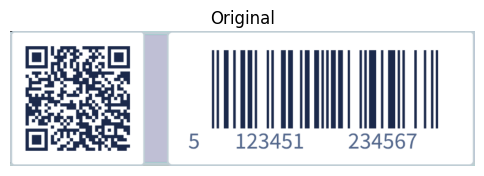

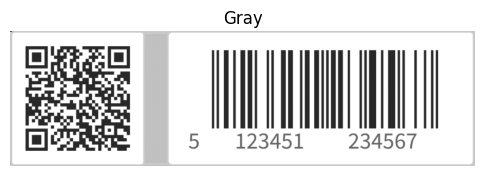

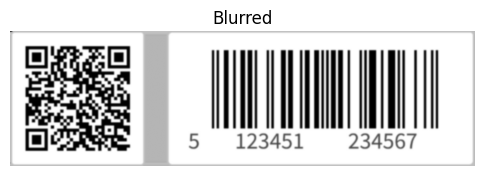

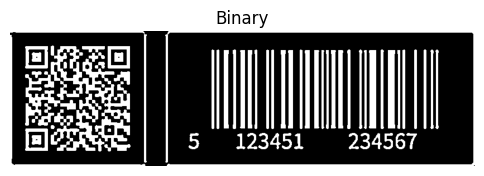

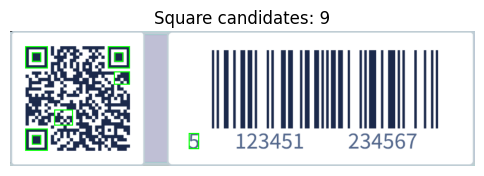

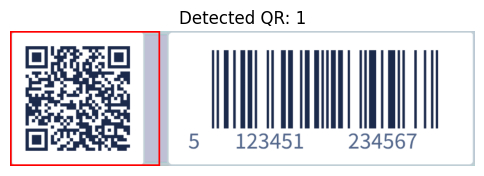

In [61]:
# DEBUG
qr_boxes, candidate_img, result_img, debug = run_qr_detection(img)

show_image(img, "Original")
show_image(normalize_to_uint8(debug["gray"]), "Gray", cmap="gray")
show_image(normalize_to_uint8(debug["blurred"]), "Blurred", cmap="gray")
show_image(debug["binary"] * 255, "Binary", cmap="gray")
show_image(candidate_img, f"Square candidates: {len(debug['square_candidates'])}")
show_image(result_img, f"Detected QR: {len(qr_boxes)}")

In [62]:
import cv2

detector = cv2.QRCodeDetector()

def decode_qr_from_box(image, box, padding=8):
    r_min, c_min, r_max, c_max = box
    H, W = image.shape[:2]

    # padding
    r0 = max(0, r_min - padding)
    c0 = max(0, c_min - padding)
    r1 = min(H - 1, r_max + padding)
    c1 = min(W - 1, c_max + padding)

    roi = image[r0:r1+1, c0:c1+1]
    roi_bgr = cv2.cvtColor(roi, cv2.COLOR_RGB2BGR)

    # First attempt
    text, points, straight = detector.detectAndDecode(roi_bgr)

    if text:
        return {"decoded": True, "text": text, "box": box}

    # Second attempt (zoom)
    roi_big = cv2.resize(roi_bgr, None, fx=2.5, fy=2.5, interpolation=cv2.INTER_CUBIC)
    text, points, straight = detector.detectAndDecode(roi_big)

    if text:
        return {"decoded": True, "text": text, "box": box}

    return {"decoded": False, "text": None, "box": box}

In [63]:
def decode_detected_qrs(image, qr_boxes, padding=8):
    """
    Decode all detected QR boxes in an image.
    """
    return [
        decode_qr_from_box(image, box, padding=padding)
        for box in qr_boxes
    ]

In [64]:
def draw_decoded_qrs(image, decoded_results):
    """
    Draw QR boxes and decoded text (visualization only).
    """
    out = Image.fromarray(image.astype(np.uint8)).convert("RGB")
    draw = ImageDraw.Draw(out)

    for item in decoded_results:
        r_min, c_min, r_max, c_max = item["box"]

        if item["decoded"]:
            color = (0, 255, 0)
            label = f"QR: {item['text']}"
        else:
            color = (255, 0, 0)
            label = "QR: not decoded"

        draw.rectangle([c_min, r_min, c_max, r_max], outline=color, width=3)
        draw.text((c_min, max(0, r_min - 18)), label, fill=color)

    return np.array(out)

In [65]:
def run_qr_pipeline_with_decoding(image):
    """
    Full QR pipeline:
    detection + decoding + visualization
    """
    qr_boxes, debug = detect_qr_codes(image, return_debug=True)

    decoded_results = decode_detected_qrs(image, qr_boxes, padding=8)
    final_img = draw_decoded_qrs(image, decoded_results)

    return final_img, decoded_results, debug

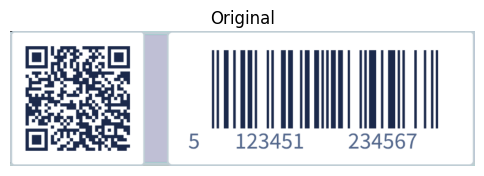

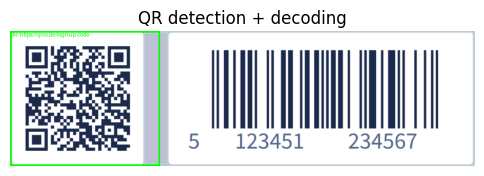

=== QR Decoding results ===

QR 1
Box     : (0, 0, 240, 268)
Decoded : True
Text    : https://qrco.de/signup-code


In [66]:
# ======================
# DEMO / TEST
# ======================

final_img, decoded_results, _ = run_qr_pipeline_with_decoding(img)

show_image(img, "Original")
show_image(final_img, "QR detection + decoding")

print("=== QR Decoding results ===")
for i, item in enumerate(decoded_results, 1):
    print(f"\nQR {i}")
    print("Box     :", item["box"])
    print("Decoded :", item["decoded"])
    print("Text    :", item["text"])

# Unified pipeline

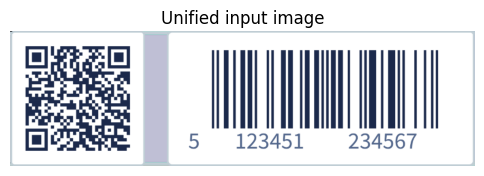

In [67]:
img_unified = load_image_from_url(
    "https://fr.qr-code-generator.com/wp-content/themes/qr/new_structure/assets/media/images/solutions/overview/QRCodeBarcode.png"
)

show_image(img_unified, "Unified input image")

In [68]:
def draw_unified_results(image, decoded_barcodes, decoded_qrs):
    """
    Draw both barcode and QR detections on the same image.
    """
    out = Image.fromarray(image.astype(np.uint8)).convert("RGB")
    draw = ImageDraw.Draw(out)

    # Draw barcodes
    for item in decoded_barcodes:
        r_min, c_min, r_max, c_max = item["box"]

        if item["decoded"]:
            color = (0, 255, 0)
            label = f"{item['type']}: {item['text']}"
        else:
            color = (255, 0, 0)
            label = "BARCODE: not decoded"

        draw.rectangle([c_min, r_min, c_max, r_max], outline=color, width=3)
        draw.text((c_min, max(0, r_min - 18)), label, fill=color)

    # Draw QR codes
    for item in decoded_qrs:
        r_min, c_min, r_max, c_max = item["box"]

        if item["decoded"]:
            color = (0, 0, 255)
            label = f"QR: {item['text']}"
        else:
            color = (255, 128, 0)
            label = "QR: not decoded"

        draw.rectangle([c_min, r_min, c_max, r_max], outline=color, width=3)
        draw.text((c_min, max(0, r_min - 18)), label, fill=color)

    return np.array(out)

In [69]:
def detect_and_decode_all_codes(image):
    """
    Unified pipeline:
    - detect barcodes
    - detect QR codes
    - decode both
    - draw all results on one image
    """
    # ---------- BARCODES ----------
    _, barcode_candidates, barcode_debug = detect_barcodes(image)
    decoded_barcodes = decode_detected_barcodes(image, barcode_candidates, padding=12)

    # ---------- QR CODES ----------
    qr_boxes, qr_debug = detect_qr_codes(image, return_debug=True)
    decoded_qrs = decode_detected_qrs(image, qr_boxes, padding=8)

    # ---------- FINAL DRAW ----------
    final_img = draw_unified_results(image, decoded_barcodes, decoded_qrs)

    debug = {
        "barcode_debug": barcode_debug,
        "qr_debug": qr_debug
    }

    return final_img, decoded_barcodes, decoded_qrs, debug


Component 1
Box         : (0, 0, 4, 24)
Aspect ratio: 5.0
Pixel area  : 125
Transitions : 0.4
Edge ratio  : 0.1941286
Fill ratio  : 1.0

Component 2
Box         : (23, 6, 217, 236)
Aspect ratio: 1.1846153846153846
Pixel area  : 44630
Transitions : 16.6974358974359
Edge ratio  : 0.98474455
Fill ratio  : 0.9907869907869908

Component 3
Box         : (30, 340, 177, 788)
Aspect ratio: 3.0337837837837838
Pixel area  : 66337
Transitions : 56.75675675675676
Edge ratio  : 22.124718
Fill ratio  : 0.9982694275567326

Component 4
Box         : (180, 299, 210, 359)
Aspect ratio: 1.967741935483871
Pixel area  : 1750
Transitions : 2.129032258064516
Edge ratio  : 0.825668
Fill ratio  : 0.9254362771020624

Component 5
Box         : (180, 385, 213, 545)
Aspect ratio: 4.735294117647059
Pixel area  : 5128
Transitions : 11.058823529411764
Edge ratio  : 1.0364028
Fill ratio  : 0.9367921081476068

Component 6
Box         : (180, 586, 212, 749)
Aspect ratio: 4.96969696969697
Pixel area  : 5030
Transitions :

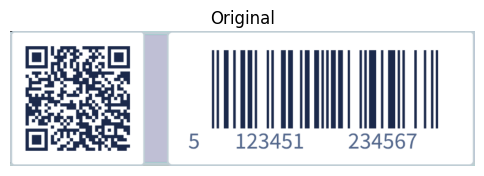

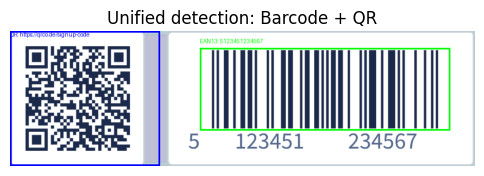

=== BARCODE RESULTS ===

Barcode 1
Box     : (30, 340, 177, 788)
Decoded : True
Text    : 5123451234567
Type    : EAN13
Angle   : 0
Version : original

=== QR RESULTS ===

QR 1
Box     : (0, 0, 240, 268)
Decoded : True
Text    : https://qrco.de/signup-code


In [70]:
final_img, decoded_barcodes, decoded_qrs, debug = detect_and_decode_all_codes(img_unified)

show_image(img_unified, "Original")
show_image(final_img, "Unified detection: Barcode + QR")

print("=== BARCODE RESULTS ===")
for i, item in enumerate(decoded_barcodes, 1):
    print(f"\nBarcode {i}")
    print("Box     :", item["box"])
    print("Decoded :", item["decoded"])
    print("Text    :", item["text"])
    print("Type    :", item["type"])
    print("Angle   :", item["angle"])
    print("Version :", item["version"])

print("\n=== QR RESULTS ===")
for i, item in enumerate(decoded_qrs, 1):
    print(f"\nQR {i}")
    print("Box     :", item["box"])
    print("Decoded :", item["decoded"])
    print("Text    :", item["text"])